# Frame Alignment

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[4.offset_calculation.ipynb](./4.offset_calculation.ipynb)|<i>5.frame_alignment.ipynb</i>|[6.eeg_ffts.ipynb](./6.eeg_ffts.ipynb)|

In the previous notebook ([4.offset_calculation.ipynb](./4.offset_calculation.ipynb)), we calculated the offset between blinks estimated from the VR with those estimated from the EEG data. In this notebook, we need to do an additional step: calculate the frames of each EEG row to the closest VR frame.

The complication herein is that the EEG data will have a higher sampling rate than the VR data. In fact, the EEG data is sampled at approximately 255Hz, while the VR data can get up to at most 90Hz. So the most optimal method, in my eyes, is to do one of two things: either:

1. Estimate the closest frame for each EEG row, or
2. Artificially increase the sample rate of the VR data to match the 255Hz of the EEg data.

Both _technically_ work, but I would be pretty afraid of losing data in the first scenario. We'd effectively be downsampling the data. We can avoid that if we just find the closest frame though (i.e. what's the closest frame number before the current EEG row's timestamp?). The second one is also fine, but it would require interpolation of a frankly massive dataset; you'd have to account for multiple rows reprsenting each frame (as we're tracking multiple objects' positions and orientations per frame). This gets exacerbated when you don't know, for each frame, how many agents are active or not.

To make our lives easier, I will only look at mapping each EEG row to the nearest VR frame below the current timestamp.

## Step 0: Imports

Note that, unlike previous notebooks, we do NOT include `P3` to our list of active participants. This is because the eye tracking data is generally bonkered in `P3`'s data. So we'll only be looking at the remaining participants.

In [34]:
import pandas as pd
import os
import importlib

from components import eeg_handling
importlib.reload(eeg_handling)

pd.set_option('display.max_colwidth', None)   # Show full cell contents
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Don't wrap lines
pd.set_option('display.float_format', '{:.10f}'.format)

_DATA_DIR = os.path.join('.','data2')
_ACTIVE_PARTICIPANTS = ['P1', 'PI2', 'P2', 'P4_Muse2', 'P5' ]

## Step 1: Calculating Corrected Timestamps

For each EEG data, we need to calculate the "corrected" timestamp by running through each timestamp with the participant's respective offset. The calculation herein is `eeg_unix_ms - offset`. Any negative offsets means that this operation pushes the EEG data forward, which makes sense because a negative offset means the EEg data comes before the VR data.

### 1a. Get offsets

In [10]:
offsets_raw = pd.read_csv(os.path.join(_DATA_DIR, 'blink_offsets.csv'))
offsets = offsets_raw[offsets_raw['eeg_channel']=='combined']
offsets.drop(columns=['eeg_channel'], inplace=True)
offsets = offsets[offsets['participant'] != 'P3']
display(offsets)

offsets_dict = offsets.set_index('participant')['offset_median'].to_dict()
display(offsets_dict)

C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_46704\4012652347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  offsets.drop(columns=['eeg_channel'], inplace=True)


,participant,offset_median
0,P1,-50
3,PI2,77
7,P2,-53
12,P4_Muse2,64
15,P5,-36


{'P1': -50.0, 'PI2': 77.0, 'P2': -53.0, 'P4_Muse2': 64.0, 'P5': -36.0}

### 1b. Calculate new timestamp offsets for EEG data

This one is a bit more complicated than I think we're expecting. Basically, we cannot just use the raw `eeg_processed.csv` and `eeg_raw.csv` data already divided in the `simulation` directory. This is because this data was generated by butting the EEG data and VR data by the same unix_ms and frame, PRIOR TO EEG TIMESTAMP CORRECTION. This means that the eeg in these data are not _really_ aligned. 

The step here is to read actual raw EEG data again, **apply the timestamp correction**, split across trials, then split across calibration vs simulation vs combined.

In [58]:
for p in offsets_dict:
    # Extract the offset and file directory of this participant
    offset = offsets_dict[p]
    pdir = os.path.join(_DATA_DIR, p)

    # Read the trial data of this participant
    trials = pd.read_csv(os.path.join(pdir, 'trials.csv'))

    # Read the EEG data. This has to come from `src/data/`
    eeg, _ = eeg_handling.read(os.path.join('.', 'data', p, 'eeg_vr.csv'))

    # We first separate, then apply the correction
    raw, processed = eeg_handling.separate(eeg)
    raw['cor_unix_ms'] = raw['unix_ms'] - offset
    processed['cor_unix_ms'] = processed['unix_ms'] - offset


    # Iterate through each trial, which will allow us to split the data
    for _, trial in trials.iterrows():
        
        # Trial ID and timestamps
        trial_id = trial['trial_id']
        trial_start_unix_ms = trial['start_unix_ms']
        trial_end_unix_ms = trial['end_unix_ms']
        sim_start_unix_ms = trial['sim_start_unix_ms']
        sim_end_unix_ms = trial['sim_end_unix_ms']

        # Extract the data for the trial itself
        trial_raw = raw[raw['cor_unix_ms'].between(trial_start_unix_ms, trial_end_unix_ms)]
        trial_processed = processed[processed['cor_unix_ms'].between(trial_start_unix_ms, trial_end_unix_ms)]

        # Extract the data for the simulation only
        sim_raw = trial_raw[trial_raw['cor_unix_ms'].between(sim_start_unix_ms, sim_end_unix_ms)]
        sim_processed = trial_processed[trial_processed['cor_unix_ms'].between(sim_start_unix_ms, sim_end_unix_ms)]

        # Save the data in their respective folders inside `src/data2/`
        combined_dir = os.path.join(pdir, f"{trial_id}", 'combined')
        trial_raw.to_csv(os.path.join(combined_dir, 'cor_eeg_raw.csv'), index=False)
        trial_processed.to_csv(os.path.join(combined_dir, 'cor_eeg_processed.csv'), index=False)
        sim_dir = os.path.join(pdir, f"{trial_id}", 'simulation')
        sim_raw.to_csv(os.path.join(sim_dir, 'cor_eeg_raw.csv'), index=False)
        sim_processed.to_csv(os.path.join(sim_dir, 'cor_eeg_processed.csv'), index=False)        


d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_46704\2645399431.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw['cor_unix_ms'] = raw['unix_ms'] - offset
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_46704\2645399431.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

## Step 2: Identifying Frames for EEG Data

One additional thing we want to do is to append a frame value to each row of the EEG data. This is another way to find a common alignment between the EEG data and the VR data `positiosn.csv`, which only contains the frame data.

Reflecting what we discussed at the beginning of the notebook, we technically have two choices: assign frames to each EEG row, or assign `unix_ms` to each row in the positions data. However, I think it might be easier to apply frames to each EEG data, as the EEG data is sampled at a higher rate. The `frame` column therefore can be considered a float value, rounded to the nearest tenth of a frame, for example.

We also have the benefit of knowing that the EEG data has been corrected in Step 1 above, so we can safely assume that the EEG data and VR data is, in some respect, aligned. We won't know for certain because the first entry position in the `positions.csv` is a frame, while the corrected EEG data only has milliseconds. However, I wish to believe that we can make this assumption safely and assume that the first frame of the `positions.csv` data of each trial truly corresponds to the first EEG data row.

In [59]:
for p in offsets_dict:
    # Extract the file directory of this participant
    pdir = os.path.join(_DATA_DIR, p)

    # Read the trial data of this participant
    trials = pd.read_csv(os.path.join(pdir, 'trials.csv'))
    
    # Iterate through each trial
    for _, trial in trials.iterrows():
        
        # Trial ID and Directory. This time, the directory leads into `simulation`
        trial_id = trial['trial_id']
        tdir = os.path.join(pdir, f"{trial_id}", 'simulation')

        # We read the corrected EEG data and the positions data
        eeg_processed = pd.read_csv(os.path.join(tdir, 'cor_eeg_processed.csv'))
        eeg_raw = pd.read_csv(os.path.join(tdir, 'cor_eeg_raw.csv'))
        positions = pd.read_csv(os.path.join(tdir, 'positions.csv'))

        # If we associate the first frame with the first unix milliseconds in the EEG data, then let's proceed from there.
        # We might have variable frame rate in the VR data, but what we DO have is the `timestamp` feature. This `timestamp` features is in seconds (presumedly) and tracks the relative timing of frames. We can use this to calculate the timing of each frame itself.
        # So let's group by frames, then get the first entry in the `timestmap` feature of the position data
        positions['timestamp'] = positions['timestamp'].astype(float)
        frames_to_second = positions.groupby('frame', as_index=False)[['timestamp','deltaTime']].first()

        # Now, let's re-center the frames and timestamps to be relative to the first frame. We don't do `deltaTime` because that's just the change in time from the last frame.
        frames_to_second['rel_frame'] = frames_to_second['frame'] - frames_to_second['frame'].iloc[0]
        frames_to_second['rel_timestamp'] = frames_to_second['timestamp'] - frames_to_second['timestamp'].iloc[0]

        # this new `frames_to_second` provides two features in accordance to each frame: a `timestamp` in seconds, and a delta time (in seconds). Let's convert them to milliseconds
        frames_to_second['rel_timestamp_ms'] = frames_to_second['rel_timestamp'] * 1000
        frames_to_second['deltaTime_ms'] = frames_to_second['deltaTime'] * 1000
        frames_to_second.iloc[0, frames_to_second.columns.get_loc('deltaTime_ms')] = 0

        # Now, let's drop the now-redundant `timestamp` and `deltaTime`
        frames_to_ms = frames_to_second.drop(columns=['timestamp', 'deltaTime'])

        # The hard part: using `detlaTime_ms` from `frames_to_ms` and `cor_unix_ms`'s delta time in the EEG data, align the two datasets.
        # Let's first start by calculating the detal time of each row in the EEG data
        eeg_processed['deltaTime_ms'] = eeg_processed['cor_unix_ms'] - eeg_processed['cor_unix_ms'].shift(1)
        eeg_processed['deltaTime_ms'] = eeg_processed['deltaTime_ms'].fillna(0)
        eeg_raw['deltaTime_ms'] = eeg_raw['cor_unix_ms'] - eeg_raw['cor_unix_ms'].shift(1)
        eeg_raw['deltaTime_ms'] = eeg_raw['deltaTime_ms'].fillna(0)

        # Next, let's accumulate the total amount of time passed fro both the EEG data and the `frames_to_ms` dataframes
        eeg_processed['total_time_ms'] = eeg_processed['deltaTime_ms'].cumsum()
        eeg_raw['total_time_ms'] = eeg_raw['deltaTime_ms'].cumsum()
        frames_to_ms['total_time_ms'] = frames_to_ms['deltaTime_ms'].cumsum()   # This is technically the same as `rel_timestamps_ms`, but we have so much more detail in the timestamp data with this new one

        # Next, we need to create a conversion ratio from frame to total time
        total_frames = frames_to_ms['rel_frame'].iloc[-1]
        total_time = frames_to_ms['total_time_ms'].iloc[-1]
        frames_per_time = total_frames / total_time

        # Now, let's create a new `rel_frame` column in the EEg data in correspondance to the total time
        eeg_processed['rel_frame'] = eeg_processed['total_time_ms'] * frames_per_time
        eeg_raw['rel_frame'] = eeg_raw['total_time_ms'] * frames_per_time

        # we need to save our new eeg data. It'll also be a good ideat o save our frame to ms dataframes
        eeg_processed.to_csv(os.path.join(tdir, 'cor_eeg_pro_framed.csv'), index=False)
        eeg_raw.to_csv(os.path.join(tdir, 'cor_eeg_raw_framed.csv'), index=False)
        frames_to_ms.to_csv(os.path.join(tdir, 'frames_to_ms.csv'), index=False)


## Testing Alignment

Let's do something funny and actually visualize our alignment our participants. Let's specifically look at `P4_Muse2`'s first trial. For that one, let's read `eye.csv` and `cor_eeg_raw_framed.csv`:`AF7`. We should be able to align them by `eye.csv`:`rel_frame` (which has to be calculated) and `cor_eeg_raw_framed.csv`:`rel_frame`. The values we'll be rendering are the x-position of the head and the signal of `AF7`.

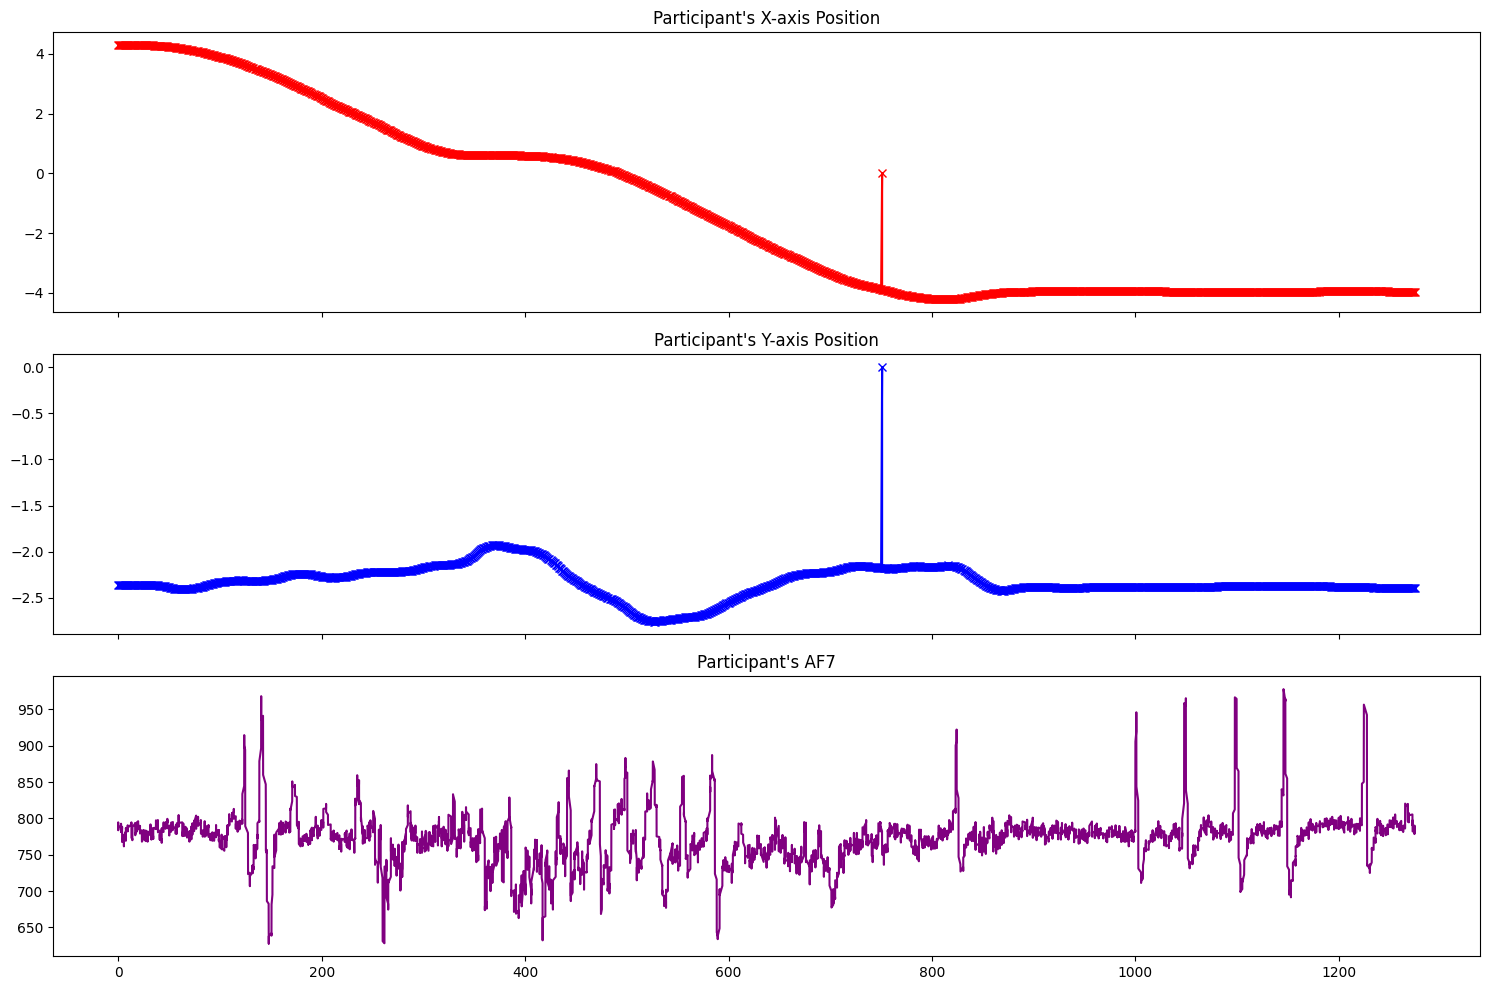

In [65]:
import matplotlib.pyplot as plt

_EXAMPLE_PARTICIPANT = 'P4_Muse2'
_TDIR = os.path.join('.', _DATA_DIR, _EXAMPLE_PARTICIPANT, '1', 'simulation')

eye = pd.read_csv(os.path.join(_TDIR, 'eye.csv'))
eeg = pd.read_csv(os.path.join(_TDIR, 'cor_eeg_raw_framed.csv'))

# Remove the first and last rows from the eye data, which actually are just event data to indicate the trial start and end
eye = eye.iloc[1:-1]

# Apply `rel_frame` to eye data
eye['rel_frame'] = eye['frame'] - eye['frame'].iloc[0]

# Get positional data
positions = eye[['unix_ms', 'frame','rel_frame', 'event', 'head_position_x','head_position_y', 'head_position_z']].rename(columns={'head_position_x':'x', 'head_position_y':'y', 'head_position_z':'z'})

# Now, start plotting the figure
fig, axes = plt.subplots(3,1,figsize=(15,10), sharex=True)
px = positions['x'].to_list()
py = positions['z'].to_list()
pt = positions['rel_frame'].to_list()

axes[0].plot(pt, px, c='red', marker='x')
axes[0].set_title("Participant's X-axis Position")
axes[1].plot(pt, py, c='blue', marker='x')
axes[1].set_title("Participant's Y-axis Position")

et = eeg['rel_frame'].to_list()
ey = eeg['AF7'].to_list()

axes[2].plot(et, ey, c='purple')
axes[2].set_title("Participant's AF7")

plt.tight_layout()
plt.show()


## What's Next

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[4.offset_calculation.ipynb](./4.offset_calculation.ipynb)|<i>5.frame_alignment.ipynb</i>|[6.eeg_ffts.ipynb](./6.eeg_ffts.ipynb)|

The next notebook, [6.eeg_ffts.ipynb](./6.eeg_ffts.ipynb), will actually start to analyze EEG data and attempt to convert it into a PSD analysis based on fast fourier transformations. We'll also attempt to identify frequencies tied to blinks and filter that data out.